In [1]:
import pandas as pd

df = pd.read_csv("student_data.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'student_data.csv'

In [2]:
import os

print("Current Jupyter folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current Jupyter folder:
C:\Users\zahra\Documents\Student_Performance_ML

Files in this folder:
['.ipynb_checkpoints', 'random_forest_model.pkl', 'student_data.csv.xls', 'Student_Performance_Prediction.ipynb', 'Untitled.ipynb']


In [3]:
import pandas as pd

df = pd.read_excel("student_data.csv.xls")

df.head()

ValueError: Excel file format cannot be determined, you must specify an engine manually.

In [4]:
import pandas as pd

df = pd.read_csv("student_data.csv.xls")

df.head()

,Name,Age,Salary,Join_Date,Department
0,Pam,25.0,70200.0,1/15/2023,HR
1,Jane,36.0,65000.0,8/1/2022,Finance
2,Alice,22.0,71350.0,5/20/2021,HR
3,Bob,22.0,71841.0,1/15/2023,IT
4,Pam,25.0,71250.0,1/15/2023,HR


In [5]:
df["Department"].value_counts()

Department
HR         22
Finance    10
IT         10
Name: count, dtype: int64

In [6]:
print("Shape:", df.shape)
df.info()

Shape: (42, 5)
<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        42 non-null     str    
 1   Age         42 non-null     float64
 2   Salary      42 non-null     float64
 3   Join_Date   42 non-null     str    
 4   Department  42 non-null     str    
dtypes: float64(2), str(3)
memory usage: 2.4 KB


Predictive Modeling Using Machine Learning
Build a model to predict outcomes based on given data.

Watch Task Tutorial
Key Features:
Apply algorithms like Linear Regression, Decision Trees, or Random Forest
Train and test models for accuracy
Visualize performance using confusion matrices or ROC curves
Expected Outcome:
Gain experience in super

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [8]:
df = pd.read_csv("student_data.csv.xls")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (42, 5)


,Name,Age,Salary,Join_Date,Department
0,Pam,25.0,70200.0,1/15/2023,HR
1,Jane,36.0,65000.0,8/1/2022,Finance
2,Alice,22.0,71350.0,5/20/2021,HR
3,Bob,22.0,71841.0,1/15/2023,IT
4,Pam,25.0,71250.0,1/15/2023,HR


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        42 non-null     str    
 1   Age         42 non-null     float64
 2   Salary      42 non-null     float64
 3   Join_Date   42 non-null     str    
 4   Department  42 non-null     str    
dtypes: float64(2), str(3)
memory usage: 2.4 KB


In [10]:
df.describe()

,Age,Salary
count,42.000000,42.000000
mean,34.690476,124031.309524
std,9.238013,183008.178720
min,21.000000,61000.000000
25%,25.000000,68500.000000
50%,36.000000,71841.000000
75%,40.750000,77421.000000
max,57.000000,921000.000000


In [11]:
df.isnull().sum()

Name          0
Age           0
Salary        0
Join_Date     0
Department    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Join_Date"] = pd.to_datetime(df["Join_Date"], errors="coerce")

df["Join_Year"] = df["Join_Date"].dt.year
df["Join_Month"] = df["Join_Date"].dt.month

df.head()

,Name,Age,Salary,Join_Date,Department,Join_Year,Join_Month
0,Pam,25.0,70200.0,2023-01-15,HR,2023,1
1,Jane,36.0,65000.0,2022-08-01,Finance,2022,8
2,Alice,22.0,71350.0,2021-05-20,HR,2021,5
3,Bob,22.0,71841.0,2023-01-15,IT,2023,1
4,Pam,25.0,71250.0,2023-01-15,HR,2023,1


In [14]:
print("Invalid dates:", df["Join_Date"].isnull().sum())

Invalid dates: 0


In [15]:
df[["Join_Date", "Join_Year", "Join_Month"]].head()

,Join_Date,Join_Year,Join_Month
0,2023-01-15,2023,1
1,2022-08-01,2022,8
2,2021-05-20,2021,5
3,2023-01-15,2023,1
4,2023-01-15,2023,1


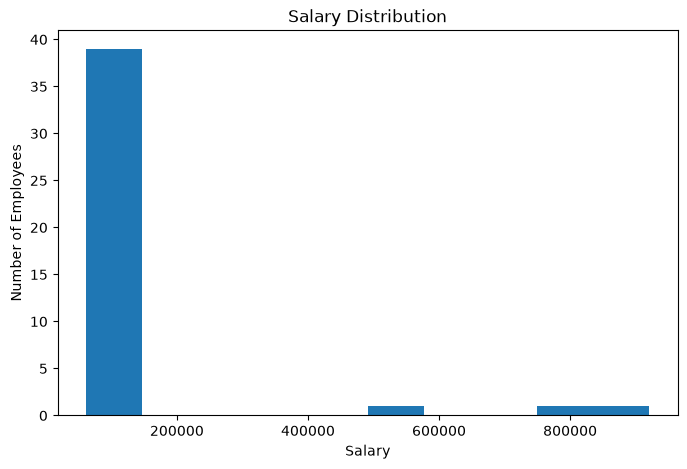

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(df["Salary"], bins=10)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")

plt.show()

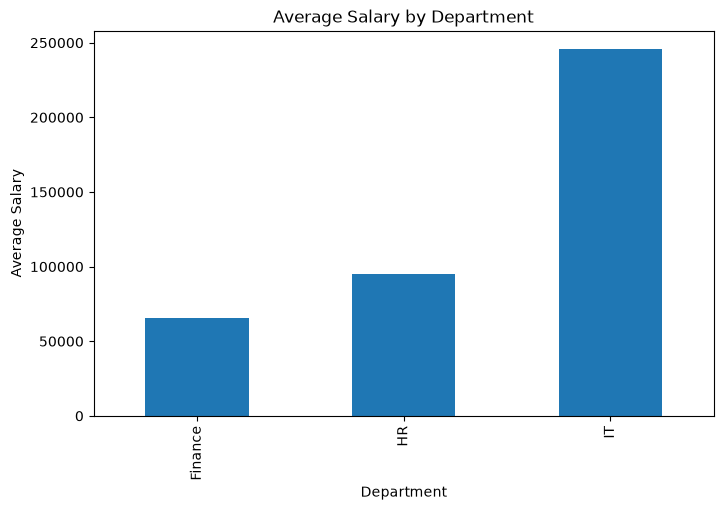

In [17]:
department_salary = df.groupby("Department")["Salary"].mean()

department_salary.plot(kind="bar", figsize=(8, 5))

plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")

plt.show()

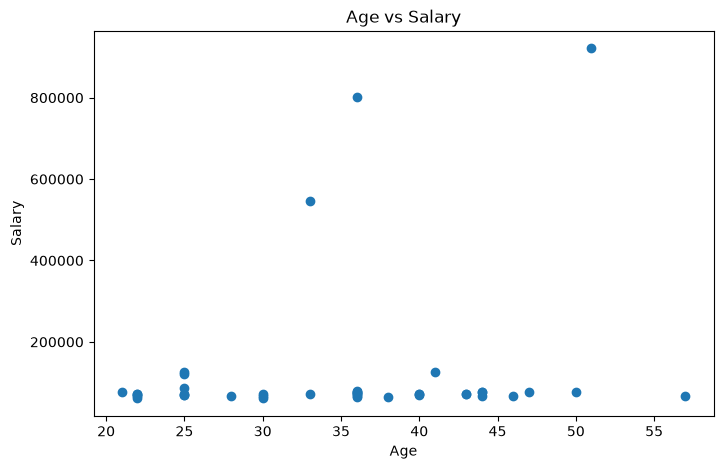

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Age"], df["Salary"])

plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")

plt.show()

In [19]:
X = df[["Age", "Department", "Join_Year", "Join_Month"]]

y = df["Salary"]

In [20]:
print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
    Age Department  Join_Year  Join_Month
0  25.0         HR       2023           1
1  36.0    Finance       2022           8
2  22.0         HR       2021           5
3  22.0         IT       2023           1
4  25.0         HR       2023           1

Target:
0    70200.0
1    65000.0
2    71350.0
3    71841.0
4    71250.0
Name: Salary, dtype: float64


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 33
Testing samples: 9


In [22]:
categorical_features = ["Department"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "department",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [23]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

lr_pred = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [24]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeRegressor(
            max_depth=4,
            random_state=42
        )
    )
])

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [25]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestRegressor(
            n_estimators=100,
            max_depth=5,
            random_state=42
        )
    )
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [26]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [27]:
results = pd.DataFrame([
    evaluate_model("Linear Regression", y_test, lr_pred),
    evaluate_model("Decision Tree", y_test, dt_pred),
    evaluate_model("Random Forest", y_test, rf_pred)
])

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,92967.497911,107310.326325,-796.934292
1,Decision Tree,8166.759259,17578.842490,-20.412366
2,Random Forest,48840.046886,82143.323111,-466.550618


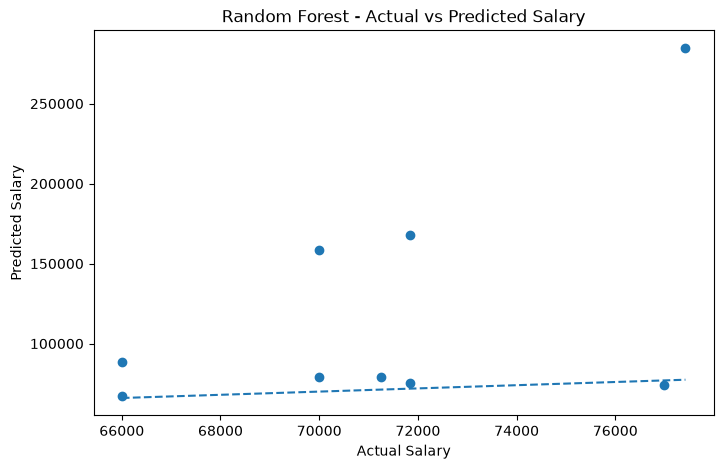

In [28]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, rf_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title("Random Forest - Actual vs Predicted Salary")

plt.show()

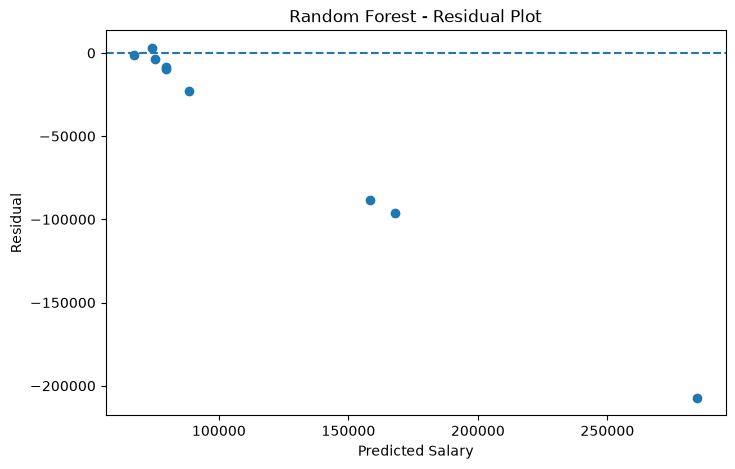

In [29]:
residuals = y_test - rf_pred

plt.figure(figsize=(8, 5))

plt.scatter(rf_pred, residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Salary")
plt.ylabel("Residual")

plt.title("Random Forest - Residual Plot")

plt.show()

In [30]:
new_employee = pd.DataFrame({
    "Age": [30],
    "Department": ["IT"],
    "Join_Year": [2024],
    "Join_Month": [6]
})

predicted_salary = rf_model.predict(new_employee)[0]

print(f"Predicted Salary: ₹{predicted_salary:,.2f}")

Predicted Salary: ₹108,387.53


In [31]:
joblib.dump(
    rf_model,
    "employee_salary_random_forest.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [32]:
loaded_model = joblib.load(
    "employee_salary_random_forest.pkl"
)

test_prediction = loaded_model.predict(new_employee)[0]

print(f"Loaded Model Prediction: ₹{test_prediction:,.2f}")

Loaded Model Prediction: ₹108,387.53


# Conclusion

In this project, machine learning techniques were used to predict
employee salary using the employee dataset.

The following steps were performed:

1. Loaded and inspected the dataset.
2. Checked missing values and duplicate records.
3. Converted the joining date into year and month features.
4. Selected Age, Department, Join Year, and Join Month as input features.
5. Used Salary as the target variable.
6. Applied one-hot encoding to the Department feature.
7. Split the dataset into training and testing sets.
8. Trained three regression models:
   - Linear Regression
   - Decision Tree Regression
   - Random Forest Regression
9. Evaluated the models using MAE, RMSE, and R² Score.
10. Visualized actual and predicted salary values.
11. Used the trained Random Forest model to predict salary for a new employee.
12. Saved the trained model as a `.pkl` file.

Since Salary is a continuous numerical variable, regression evaluation
metrics such as MAE, RMSE, and R² are more appropriate than a confusion
matrix or ROC curve.

The dataset contains only 42 records, so the model results are intended
for educational purposes and should not be considered a production-level
salary prediction system.